# Cross-Asset ETF Momentum Rotation

One cumulative pipeline covering project Stages 01–12. All analysis is educational and not investment advice.

In [1]:
# --- run me first ---
from pathlib import Path
import os, sys

import ipynbname

try:
    ROOT = Path(ipynbname.path()).resolve().parents[1]
except (FileNotFoundError, IndexError):
    ROOT = Path.cwd().resolve()
    if ROOT.name == 'notebooks':
        ROOT = ROOT.parent
    elif not (ROOT / 'src').is_dir() and (ROOT / 'project' / 'src').is_dir():
        ROOT = ROOT / 'project'
if not (ROOT / 'src').is_dir():
    raise RuntimeError(f'Could not locate the project root from {Path.cwd()}')
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('working from:', ROOT.name)

working from: project


In [2]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.cleaning import clean_prices
from src.config import (
    BENCHMARK,
    END_DATE,
    IMAGES_DIR,
    MODEL_DIR,
    PROCESSED_DIR,
    RAW_DIR,
    REPORTS_DIR,
    START_DATE,
    TICKERS,
    create_project_directories,
)
from src.data import download_etf_prices
from src.eda import eda_summary
from src.evaluation import bootstrap_mean_interval, regression_metrics, strategy_metrics
from src.features import add_market_features
from src.modeling import fit_return_model, prepare_model_data
from src.outliers import flag_iqr_by_group, winsorize_by_group
from src.storage import read_df, write_df
from src.strategy import run_momentum_rotation
from src.utils import require_columns, summarize_missing

sns.set_theme(style='whitegrid')
create_project_directories()

### Stage 01: Problem Framing and Scoping

The project tests whether a transparent six-month momentum rule can guide monthly allocation across major ETF asset classes. An investment analyst needs return, volatility, drawdown, benchmark comparison, and clear risk assumptions before deciding whether deeper research is justified.

### Stage 02: Tooling Setup

The project uses one cumulative notebook, reusable modules in `src/`, environment-driven paths, and separate raw, processed, model, documentation, and reporting folders.

In [3]:
project_directories = [RAW_DIR, PROCESSED_DIR, IMAGES_DIR, MODEL_DIR, REPORTS_DIR]
pd.Series([path.relative_to(ROOT).as_posix() for path in project_directories], name='project_directory')

0          data/raw
1    data/processed
2    reports/images
3             model
4           reports
Name: project_directory, dtype: object

### Stage 03: Python Fundamentals

The reusable schema check below is a small example of moving repeated logic from a notebook into `src/utils.py`.

In [4]:
strategy_parameters = pd.DataFrame({
    'parameter': ['universe_size', 'lookback_months', 'top_n', 'rebalance_frequency'],
    'value': [len(TICKERS), 6, 2, 'monthly'],
})
require_columns(strategy_parameters, ['parameter', 'value'])
strategy_parameters

,parameter,value
0,universe_size,8
1,lookback_months,6
2,top_n,2
3,rebalance_frequency,monthly


### Stage 04: Data Acquisition and Ingestion

Adjusted daily close and volume data are downloaded from Yahoo Finance through `yfinance`. No API key is required. The response is reshaped to long format and saved without cleaning.

In [5]:
raw_prices = download_etf_prices(TICKERS, START_DATE, END_DATE)
raw_path = write_df(raw_prices, RAW_DIR / 'etf_prices_raw.csv')

require_columns(raw_prices, ['date', 'ticker', 'close', 'volume'])
assert set(raw_prices['ticker']) == set(TICKERS)
assert raw_prices['close'].gt(0).all()

print(f'Saved {len(raw_prices):,} observations to {raw_path.relative_to(ROOT).as_posix()}')
raw_prices.groupby('ticker').agg(first_date=('date', 'min'), last_date=('date', 'max'), rows=('date', 'size'))

Saved 21,416 observations to data/raw/etf_prices_raw.csv


,first_date,last_date,rows
ticker,,,
DBC,2016-01-04,2026-08-26,2677
EEM,2016-01-04,2026-08-26,2677
EFA,2016-01-04,2026-08-26,2677
GLD,2016-01-04,2026-08-26,2677
IEF,2016-01-04,2026-08-26,2677
SPY,2016-01-04,2026-08-26,2677
TLT,2016-01-04,2026-08-26,2677
VNQ,2016-01-04,2026-08-26,2677


### Stage 05: Data Storage

CSV is the raw portable format. The saved file is reloaded and validated before any transformation. Processed tables later use Parquet to preserve data types.

In [6]:
raw_reloaded = read_df(raw_path, parse_dates=['date'])
storage_validation = pd.Series({
    'shape_matches': raw_reloaded.shape == raw_prices.shape,
    'date_is_datetime': pd.api.types.is_datetime64_any_dtype(raw_reloaded['date']),
    'close_is_numeric': pd.api.types.is_numeric_dtype(raw_reloaded['close']),
    'all_tickers_present': set(raw_reloaded['ticker']) == set(TICKERS),
}, name='passed')
assert storage_validation.all()
storage_validation

shape_matches          True
date_is_datetime       True
close_is_numeric       True
all_tickers_present    True
Name: passed, dtype: bool

### Stage 06: Data Preprocessing

Dates and numeric fields are parsed, duplicate ticker-date rows are removed, missing volume is set to zero, and invalid prices are excluded. Raw data remain unchanged.

In [7]:
cleaned_prices = clean_prices(raw_reloaded)
cleaned_path = write_df(cleaned_prices, PROCESSED_DIR / 'etf_prices_cleaned.parquet')
cleaned_reloaded = read_df(cleaned_path)

cleaning_comparison = pd.DataFrame({
    'raw': [len(raw_reloaded), raw_reloaded.duplicated(['date', 'ticker']).sum(), raw_reloaded.isna().sum().sum()],
    'cleaned': [len(cleaned_reloaded), cleaned_reloaded.duplicated(['date', 'ticker']).sum(), cleaned_reloaded.isna().sum().sum()],
}, index=['rows', 'duplicate_keys', 'missing_values'])
assert cleaned_reloaded.duplicated(['date', 'ticker']).sum() == 0
assert cleaned_reloaded['close'].gt(0).all()
cleaning_comparison

,raw,cleaned
rows,21416,21416
duplicate_keys,0,0
missing_values,0,0


### Stage 07: Outliers and Risk Assumptions

Daily-return outliers are flagged within each ETF by the 1.5-IQR rule. A 1%/99% winsorized return is created for sensitivity analysis, but the original return is preserved.

In [8]:
outlier_data = cleaned_reloaded.sort_values(['ticker', 'date']).copy()
outlier_data['return_1d'] = outlier_data.groupby('ticker')['close'].pct_change(fill_method=None)
outlier_data['outlier_iqr'] = flag_iqr_by_group(outlier_data, 'return_1d')
outlier_data['return_winsorized'] = winsorize_by_group(outlier_data, 'return_1d')
write_df(outlier_data, PROCESSED_DIR / 'outlier_analysis.parquet')

outlier_summary = outlier_data.groupby('ticker').agg(
    observations=('return_1d', 'count'),
    flagged=('outlier_iqr', 'sum'),
    minimum_return=('return_1d', 'min'),
    maximum_return=('return_1d', 'max'),
)
outlier_summary['flagged_share'] = outlier_summary['flagged'] / outlier_summary['observations']
outlier_summary

,observations,flagged,minimum_return,maximum_return,flagged_share
ticker,,,,,
DBC,2676,94,-0.079444,0.047990,0.035127
EEM,2676,107,-0.124792,0.080529,0.039985
EFA,2676,133,-0.109902,0.084731,0.049701
GLD,2676,128,-0.102742,0.063587,0.047833
IEF,2676,88,-0.025072,0.026417,0.032885
SPY,2676,179,-0.109424,0.105019,0.066891
TLT,2676,73,-0.066684,0.075195,0.027280
VNQ,2676,115,-0.177277,0.089967,0.042975


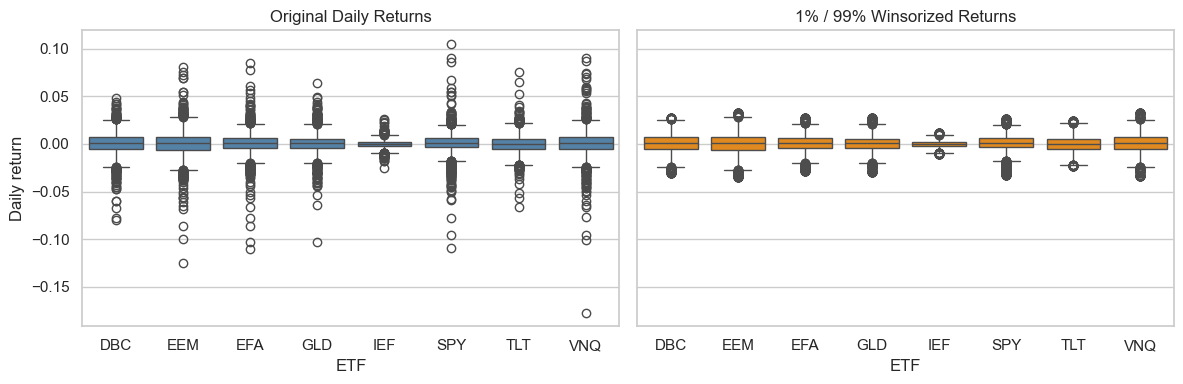

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.boxplot(data=outlier_data, x='ticker', y='return_1d', ax=axes[0], color='steelblue')
sns.boxplot(data=outlier_data, x='ticker', y='return_winsorized', ax=axes[1], color='darkorange')
axes[0].set_title('Original Daily Returns')
axes[1].set_title('1% / 99% Winsorized Returns')
for axis in axes:
    axis.set_xlabel('ETF')
    axis.set_ylabel('Daily return')
fig.tight_layout()
fig.savefig(IMAGES_DIR / 'outlier_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### Stage 08: Exploratory Data Analysis

EDA checks coverage, missingness, distributions, cross-asset price paths, and relationships between trading activity and absolute returns. Prices are normalized before cross-ETF comparison because their levels differ.

In [10]:
summary = eda_summary(outlier_data)
print('Shape:', summary['shape'])
print('Date range:', summary['date_min'].date(), 'to', summary['date_max'].date())
print('Rows by ticker:', summary['rows_by_ticker'])
display(summarize_missing(outlier_data))
display(summary['numeric_profile'])

Shape: (21416, 7)
Date range: 2016-01-04 to 2026-08-26
Rows by ticker: {'DBC': 2677, 'EEM': 2677, 'EFA': 2677, 'GLD': 2677, 'IEF': 2677, 'SPY': 2677, 'TLT': 2677, 'VNQ': 2677}


,missing_count,missing_share
return_1d,8,0.000374
return_winsorized,8,0.000374


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
close,21416.0,1.178147e+02,1.254719e+02,9.136449,4.740350e+01,8.497757e+01,1.202525e+02,7.778800e+02,2.520580,6.861023
volume,21416.0,2.412677e+07,3.164887e+07,140800.000000,4.469150e+06,1.034155e+07,3.248535e+07,3.922207e+08,2.755002,12.701596
return_1d,21408.0,3.628862e-04,1.073832e-02,-0.177277,-4.554312e-03,5.794827e-04,5.594257e-03,1.050193e-01,-0.622931,13.693623
return_winsorized,21408.0,3.828924e-04,9.613380e-03,-0.034405,-4.554312e-03,5.794827e-04,5.594257e-03,3.273579e-02,-0.189704,1.427767


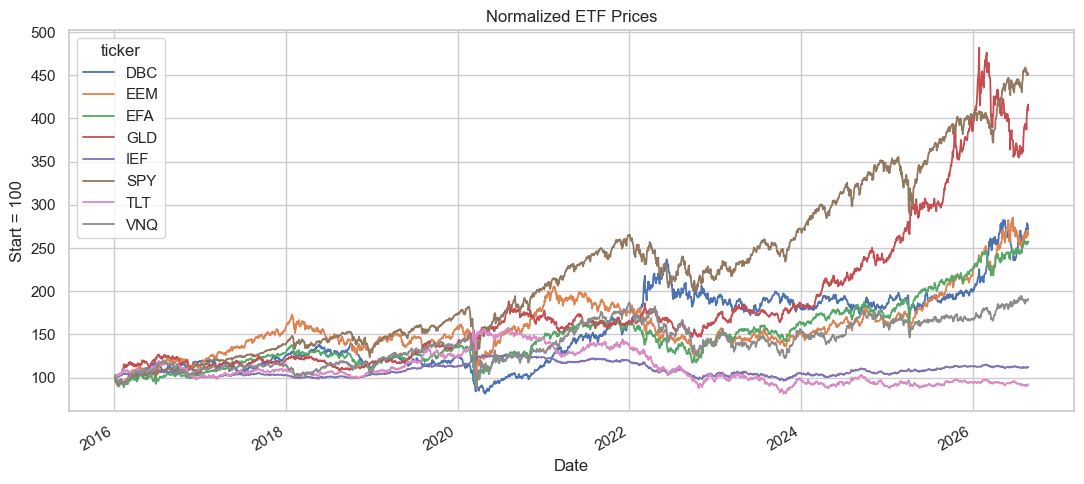

In [11]:
close_wide = outlier_data.pivot(index='date', columns='ticker', values='close').sort_index()
normalized_prices = close_wide.div(close_wide.iloc[0]).mul(100)

fig, ax = plt.subplots(figsize=(11, 5))
normalized_prices.plot(ax=ax, linewidth=1.3)
ax.set(title='Normalized ETF Prices', xlabel='Date', ylabel='Start = 100')
fig.tight_layout()
fig.savefig(IMAGES_DIR / 'normalized_prices.png', dpi=300, bbox_inches='tight')
plt.show()

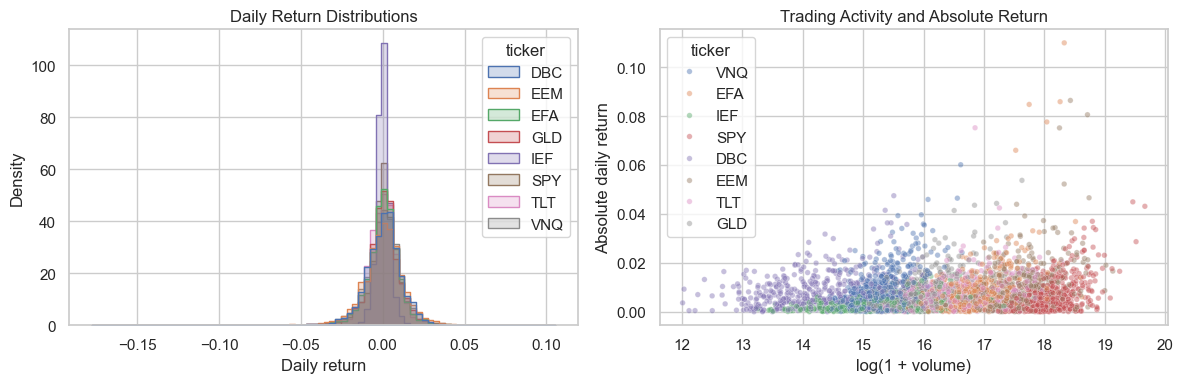

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=outlier_data, x='return_1d', hue='ticker', bins=80, element='step', stat='density', common_norm=False, ax=axes[0])
axes[0].set(title='Daily Return Distributions', xlabel='Daily return')

relationship_data = outlier_data.assign(
    log_volume=np.log1p(outlier_data['volume']),
    abs_return=outlier_data['return_1d'].abs(),
).dropna(subset=['return_1d'])
sns.scatterplot(data=relationship_data.sample(min(4000, len(relationship_data)), random_state=7), x='log_volume', y='abs_return', hue='ticker', s=16, alpha=0.45, ax=axes[1])
axes[1].set(title='Trading Activity and Absolute Return', xlabel='log(1 + volume)', ylabel='Absolute daily return')
fig.tight_layout()
fig.savefig(IMAGES_DIR / 'distributions_relationships.png', dpi=300, bbox_inches='tight')
plt.show()

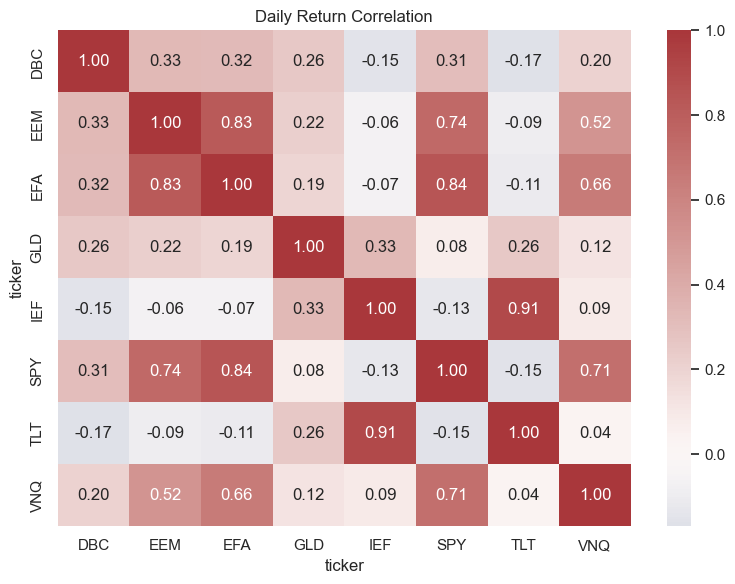

In [13]:
return_correlation = outlier_data.pivot(index='date', columns='ticker', values='return_1d').corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(return_correlation, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax)
ax.set_title('Daily Return Correlation')
fig.tight_layout()
fig.savefig(IMAGES_DIR / 'return_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

### Stage 09: Feature Engineering

Features follow the EDA findings: returns replace incomparable price levels, momentum represents relative strength, volatility and drawdown represent risk state, and ticker indicators represent persistent cross-asset differences. The target is shifted forward one trading day.

In [14]:
feature_data = add_market_features(cleaned_reloaded)
feature_data['outlier_iqr'] = flag_iqr_by_group(feature_data, 'return_1d')
feature_data['return_winsorized'] = winsorize_by_group(feature_data, 'return_1d')
feature_path = write_df(feature_data, PROCESSED_DIR / 'etf_features.parquet')

feature_availability = feature_data[
    ['return_1d', 'momentum_21d', 'momentum_63d', 'momentum_126d', 'volatility_21d', 'drawdown_63d', 'next_day_return']
].notna().mean().rename('available_share')
print('Saved:', feature_path.relative_to(ROOT).as_posix())
feature_availability

Saved: data/processed/etf_features.parquet


return_1d          0.999626
momentum_21d       0.992155
momentum_63d       0.976466
momentum_126d      0.952932
volatility_21d     0.992155
drawdown_63d       0.976840
next_day_return    0.999626
Name: available_share, dtype: float64

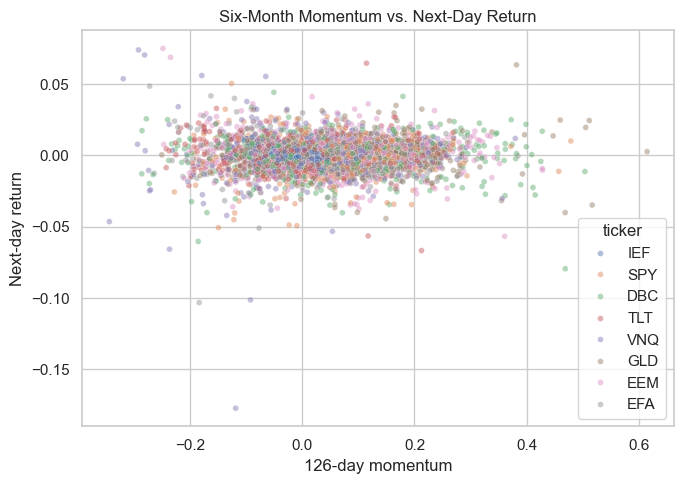

In [15]:
feature_plot_data = feature_data.dropna(subset=['momentum_126d', 'next_day_return'])
feature_plot_data = feature_plot_data.sample(min(5000, len(feature_plot_data)), random_state=7)
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=feature_plot_data, x='momentum_126d', y='next_day_return', hue='ticker', s=18, alpha=0.45, ax=ax)
ax.set(title='Six-Month Momentum vs. Next-Day Return', xlabel='126-day momentum', ylabel='Next-day return')
fig.tight_layout()
fig.savefig(IMAGES_DIR / 'momentum_vs_target.png', dpi=300, bbox_inches='tight')
plt.show()

### Stage 10: Time-Series Modeling and Strategy Backtest

The pooled linear regression is a diagnostic baseline. The split is chronological, so every test date follows every training date. The investment rule remains the lagged monthly top-two momentum rotation; turnover supports a simple transaction-cost sensitivity.

In [16]:
train_data, test_data, model_features = prepare_model_data(feature_data)
return_model, predictions = fit_return_model(train_data, test_data, model_features)
full_model_metrics = regression_metrics(predictions)

write_df(predictions, PROCESSED_DIR / 'model_predictions.csv')
with (MODEL_DIR / 'return_model.pkl').open('wb') as model_file:
    pickle.dump({'model': return_model, 'features': model_features}, model_file)

print('Train dates:', train_data['date'].min().date(), 'to', train_data['date'].max().date())
print('Test dates:', test_data['date'].min().date(), 'to', test_data['date'].max().date())
pd.Series(full_model_metrics, name='full_sample_training')

Train dates: 2016-07-05 to 2024-08-12
Test dates: 2024-08-13 to 2026-08-25


mae              0.007339
rmse             0.010745
r2               0.002896
sign_accuracy    0.525980
Name: full_sample_training, dtype: float64

In [17]:
backtest, signal_weights = run_momentum_rotation(cleaned_reloaded, benchmark=BENCHMARK, lookback_months=6, top_n=2)
TRADING_COST_BPS = 10.0
backtest['strategy_return_net_10bps'] = (
    backtest['strategy_return'] - backtest['turnover'] * TRADING_COST_BPS / 10_000
)
backtest['strategy_net_growth_10bps'] = (1 + backtest['strategy_return_net_10bps']).cumprod()
write_df(backtest.reset_index(), PROCESSED_DIR / 'monthly_backtest.csv')
write_df(signal_weights.reset_index(), PROCESSED_DIR / 'monthly_signal_weights.csv')

strategy_performance = strategy_metrics(backtest['strategy_return'])
net_strategy_performance = strategy_metrics(backtest['strategy_return_net_10bps'])
benchmark_performance = strategy_metrics(backtest['benchmark_return'])
performance_table = pd.DataFrame({
    'momentum_gross': strategy_performance,
    'momentum_net_10bps': net_strategy_performance,
    'SPY_benchmark': benchmark_performance,
}).T
performance_table

,annual_return,annual_volatility,sharpe_ratio,max_drawdown,total_return
momentum_gross,0.092395,0.127309,0.759959,-0.195791,1.419891
momentum_net_10bps,0.084497,0.127345,0.702423,-0.200678,1.250516
SPY_benchmark,0.149819,0.153246,0.992479,-0.239272,3.039186


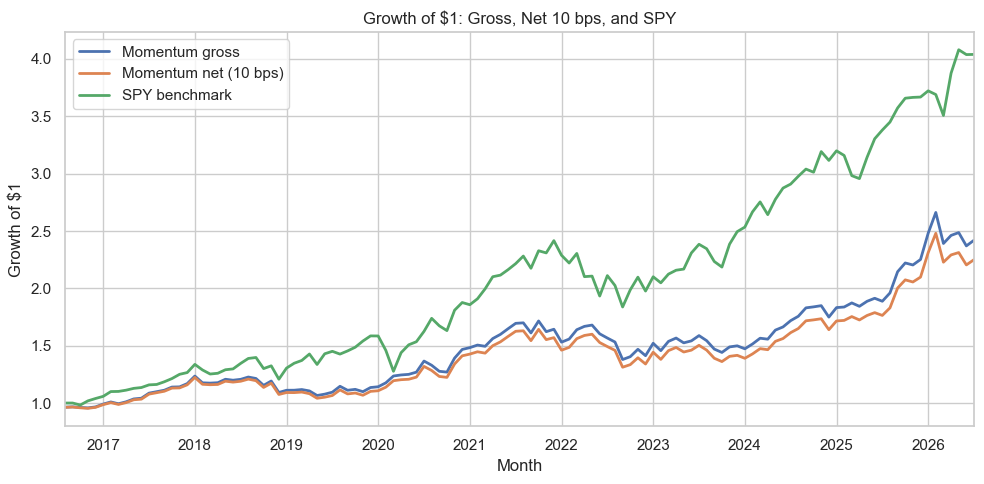

In [18]:
growth_plot = backtest[['strategy_growth', 'strategy_net_growth_10bps', 'benchmark_growth']].rename(columns={
    'strategy_growth': 'Momentum gross',
    'strategy_net_growth_10bps': 'Momentum net (10 bps)',
    'benchmark_growth': 'SPY benchmark',
})
fig, ax = plt.subplots(figsize=(10, 5))
growth_plot.plot(ax=ax, linewidth=2)
ax.set(title='Growth of $1: Gross, Net 10 bps, and SPY', xlabel='Month', ylabel='Growth of $1')
fig.tight_layout()
fig.savefig(IMAGES_DIR / 'strategy_vs_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()

### Stage 11: Evaluation and Risk Communication

The model is refitted after removing rows flagged by IQR thresholds calculated from the training set only, then evaluated on the same untouched test set. Strategy uncertainty is summarized with an IID bootstrap interval for mean monthly return; autocorrelation remains a limitation.

In [19]:
training_outlier_flag = flag_iqr_by_group(train_data, 'return_1d')
filtered_train = train_data.loc[~training_outlier_flag].copy()
filtered_model, filtered_predictions = fit_return_model(filtered_train, test_data, model_features)
filtered_model_metrics = regression_metrics(filtered_predictions)

model_sensitivity = pd.DataFrame({
    'all_training_rows': full_model_metrics,
    'exclude_iqr_outliers': filtered_model_metrics,
}).T
model_sensitivity

,mae,rmse,r2,sign_accuracy
all_training_rows,0.007339,0.010745,0.002896,0.525980
exclude_iqr_outliers,0.007336,0.010748,0.002458,0.539216


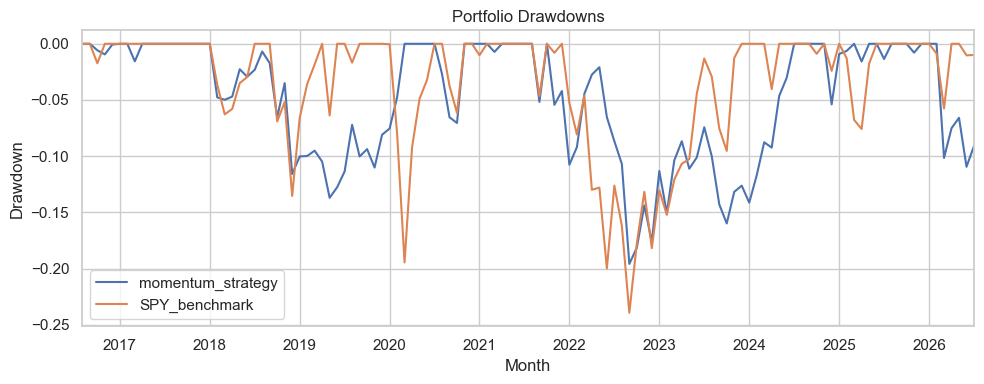

95% bootstrap interval for mean monthly strategy return: 0.1443% to 1.4306%


bootstrap_monthly_mean_lower_95    0.001443
bootstrap_monthly_mean_upper_95    0.014306
strategy_max_drawdown             -0.195791
benchmark_max_drawdown            -0.239272
average_monthly_turnover           0.608333
annual_return_cost_drag_10bps      0.007898
Name: value, dtype: float64

In [20]:
monthly_mean_ci = bootstrap_mean_interval(backtest['strategy_return'])
drawdowns = pd.DataFrame({
    'momentum_strategy': backtest['strategy_growth'] / backtest['strategy_growth'].cummax() - 1,
    'SPY_benchmark': backtest['benchmark_growth'] / backtest['benchmark_growth'].cummax() - 1,
})
risk_summary = pd.Series({
    'bootstrap_monthly_mean_lower_95': monthly_mean_ci[0],
    'bootstrap_monthly_mean_upper_95': monthly_mean_ci[1],
    'strategy_max_drawdown': strategy_performance['max_drawdown'],
    'benchmark_max_drawdown': benchmark_performance['max_drawdown'],
    'average_monthly_turnover': backtest['turnover'].mean(),
    'annual_return_cost_drag_10bps': strategy_performance['annual_return'] - net_strategy_performance['annual_return'],
}, name='value')

fig, ax = plt.subplots(figsize=(10, 4))
drawdowns.plot(ax=ax)
ax.set(title='Portfolio Drawdowns', xlabel='Month', ylabel='Drawdown')
fig.tight_layout()
fig.savefig(IMAGES_DIR / 'drawdowns.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'95% bootstrap interval for mean monthly strategy return: {monthly_mean_ci[0]:.4%} to {monthly_mean_ci[1]:.4%}')
risk_summary

### Stage 12: Results Reporting and Delivery Design

The final artifacts separate reusable code from stakeholder-facing results. The executive summary reports decisions and risks rather than presenting raw notebook output alone.

In [21]:
performance_table.to_csv(REPORTS_DIR / 'strategy_metrics.csv')
model_sensitivity.to_csv(REPORTS_DIR / 'model_sensitivity.csv')
risk_summary.to_csv(REPORTS_DIR / 'risk_summary.csv', header=True)

latest_signal_date = signal_weights.index[-1]
latest_selection = signal_weights.iloc[-1]
latest_selection = latest_selection[latest_selection > 0].index.tolist()
relative_result = 'outperformed' if strategy_performance['annual_return'] > benchmark_performance['annual_return'] else 'underperformed'
data_cutoff = cleaned_reloaded['date'].max().date()

executive_summary = f'''# Executive Summary

## Headline

The six-month ETF momentum rotation {relative_result} SPY on gross annualized return through {data_cutoff}. A 10 bps-per-traded-dollar sensitivity lowers the strategy result, while the strategy still reduces maximum drawdown.

## Results

- Momentum gross annualized return: {strategy_performance['annual_return']:.2%}
- Momentum net annualized return at 10 bps: {net_strategy_performance['annual_return']:.2%}
- Momentum annualized volatility: {strategy_performance['annual_volatility']:.2%}
- Momentum gross Sharpe ratio: {strategy_performance['sharpe_ratio']:.2f}
- Momentum net Sharpe ratio at 10 bps: {net_strategy_performance['sharpe_ratio']:.2f}
- Average monthly turnover: {backtest['turnover'].mean():.1%}
- Momentum maximum drawdown: {strategy_performance['max_drawdown']:.2%}
- SPY annualized return: {benchmark_performance['annual_return']:.2%}
- SPY annualized volatility: {benchmark_performance['annual_volatility']:.2%}
- SPY Sharpe ratio: {benchmark_performance['sharpe_ratio']:.2f}
- SPY maximum drawdown: {benchmark_performance['max_drawdown']:.2%}
- Regression test R-squared: {full_model_metrics['r2']:.3f}
- Regression sign accuracy: {full_model_metrics['sign_accuracy']:.1%}
- Outlier-filtered sign accuracy: {filtered_model_metrics['sign_accuracy']:.1%}
- 95% bootstrap interval for mean monthly strategy return: {monthly_mean_ci[0]:.3%} to {monthly_mean_ci[1]:.3%}
- Latest completed-month signal ({latest_signal_date.date()}): {', '.join(latest_selection)}

## Decision Implication

The rule is useful as a transparent diversification baseline, but these results do not justify deployment. Further work should test alternate lookbacks and cost levels, walk-forward stability, and an investable cash rule without selecting parameters on the final test period.

## Main Risks

The cost sensitivity uses a constant 10 bps rate and does not model taxes, bid-ask variation, liquidity, or market impact. The fixed ETF universe creates selection and survivorship bias. The regression has very limited predictive power. The bootstrap interval treats monthly observations as independent, and momentum can fail when market leadership reverses quickly.
'''
(REPORTS_DIR / 'executive_summary.md').write_text(executive_summary, encoding='utf-8')
print(executive_summary)

# Executive Summary

## Headline

The six-month ETF momentum rotation underperformed SPY on gross annualized return through 2026-08-26. A 10 bps-per-traded-dollar sensitivity lowers the strategy result, while the strategy still reduces maximum drawdown.

## Results

- Momentum gross annualized return: 9.24%
- Momentum net annualized return at 10 bps: 8.45%
- Momentum annualized volatility: 12.73%
- Momentum gross Sharpe ratio: 0.76
- Momentum net Sharpe ratio at 10 bps: 0.70
- Average monthly turnover: 60.8%
- Momentum maximum drawdown: -19.58%
- SPY annualized return: 14.98%
- SPY annualized volatility: 15.32%
- SPY Sharpe ratio: 0.99
- SPY maximum drawdown: -23.93%
- Regression test R-squared: 0.003
- Regression sign accuracy: 52.6%
- Outlier-filtered sign accuracy: 53.9%
- 95% bootstrap interval for mean monthly strategy return: 0.144% to 1.431%
- Latest completed-month signal (2026-07-31): DBC, VNQ

## Decision Implication

The rule is useful as a transparent diversification baseli

In [22]:
required_outputs = [
    RAW_DIR / 'etf_prices_raw.csv',
    PROCESSED_DIR / 'etf_prices_cleaned.parquet',
    PROCESSED_DIR / 'etf_features.parquet',
    PROCESSED_DIR / 'monthly_backtest.csv',
    MODEL_DIR / 'return_model.pkl',
    REPORTS_DIR / 'strategy_metrics.csv',
    REPORTS_DIR / 'model_sensitivity.csv',
    REPORTS_DIR / 'risk_summary.csv',
    REPORTS_DIR / 'executive_summary.md',
    IMAGES_DIR / 'strategy_vs_benchmark.png',
]
artifact_check = pd.Series({path.relative_to(ROOT).as_posix(): path.exists() for path in required_outputs}, name='exists')
assert artifact_check.all()
artifact_check

data/raw/etf_prices_raw.csv                  True
data/processed/etf_prices_cleaned.parquet    True
data/processed/etf_features.parquet          True
data/processed/monthly_backtest.csv          True
model/return_model.pkl                       True
reports/strategy_metrics.csv                 True
reports/model_sensitivity.csv                True
reports/risk_summary.csv                     True
reports/executive_summary.md                 True
reports/images/strategy_vs_benchmark.png     True
Name: exists, dtype: bool

### Project Status

The research pipeline is complete through Stage 12. Productization, deployment, monitoring, and orchestration are intentionally deferred until the analysis is reviewed.